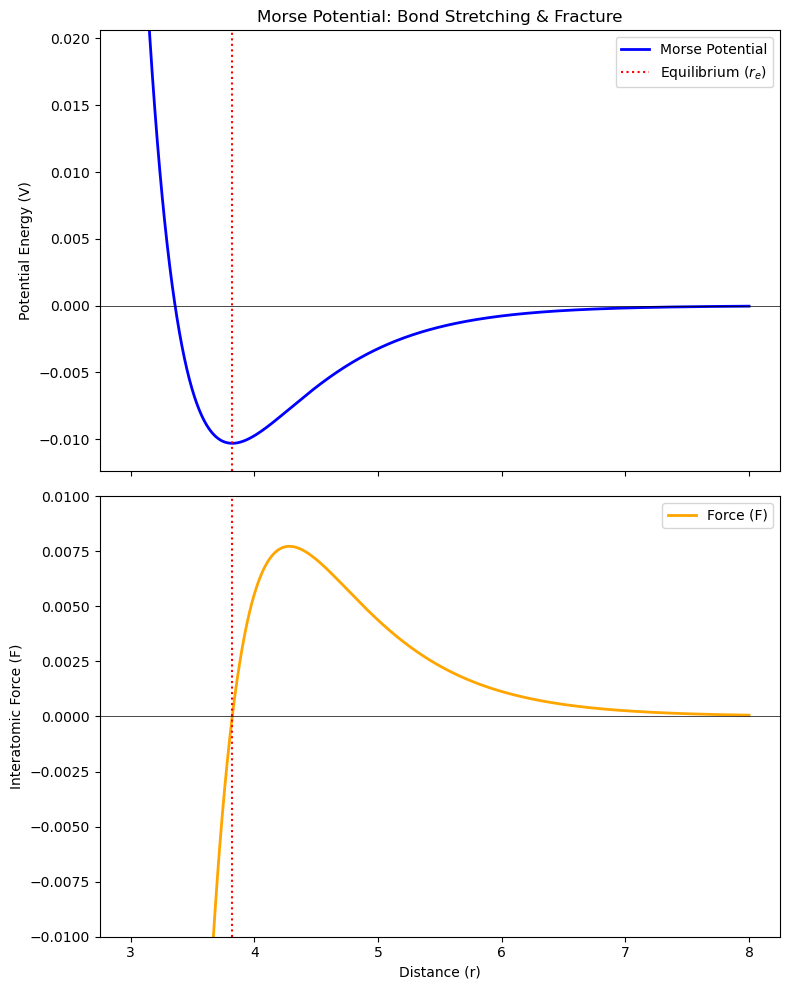

In [38]:
import numpy as np
import matplotlib.pyplot as plt

class InteratomicPotential():
    def __init__(self, parameters):
        self.parameters = parameters

class MorsePotential(InteratomicPotential):
    class Parameters():
        def __init__(self, De, a, re):
            self.De = De   # Dissociation energy (well depth)
            self.a = a     # Controls "width" / stiffness
            self.re = re   # Equilibrium distance

    def eval(self, r):
        De, a, re = self.parameters.De, self.parameters.a, self.parameters.re
        # V(r) = De * [ (1 - e^-a(r-re))^2 - 1 ]
        # Subtracting 1 shifts the minimum to -De for easier comparison to LJ
        return De * ((1 - np.exp(-a * (r - re)))**2 - 1)

    def force_analytical(self, r):
        De, a, re = self.parameters.De, self.parameters.a, self.parameters.re
        # F(r) = -dV/dr = 2 * a * De * (1 - e^-a(r-re)) * e^-a(r-re)
        exptouch = np.exp(-a * (r - re))
        return 2 * a * De * (1 - exptouch) * exptouch

# 1. Setup Parameters (Using values similar to your Argon LJ setup)
# re = 3.822 matches the LJ equilibrium for sigma=3.405
morse_args = MorsePotential.Parameters(De=0.0103, a=1.5, re=3.822)
o = MorsePotential(parameters=morse_args)

# 2. Generate Data
r_arr = np.linspace(3.0, 8.0, 1000)
V_arr = o.eval(r_arr)
# Analytical force is much cleaner for plotting fracture
F_arr = o.force_analytical(r_arr) 

# 3. Plotting
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

# Top Plot: Potential Energy (The "Well")
ax[0].plot(r_arr, V_arr, label='Morse Potential', color='blue', lw=2)
ax[0].axvline(o.parameters.re, color='red', linestyle=':', label='Equilibrium ($r_e$)')
ax[0].axhline(0, color='black', lw=0.5)
ax[0].set_ylabel('Potential Energy (V)')
ax[0].set_title('Morse Potential: Bond Stretching & Fracture')
# Zoom in on the well so it doesn't look flat
ax[0].set_ylim(-o.parameters.De * 1.2, o.parameters.De * 2) 
ax[0].legend()

# Bottom Plot: Force
ax[1].plot(r_arr, F_arr, label='Force (F)', color='orange', lw=2)
ax[1].axvline(o.parameters.re, color='red', linestyle=':')
ax[1].axhline(0, color='black', lw=0.5)
ax[1].set_ylabel('Interatomic Force (F)')
ax[1].set_xlabel('Distance (r)')
ax[1].set_ylim(-0.01, 0.01) 
# The peak force is where the bond "snaps"
ax[1].legend()

plt.tight_layout()
plt.show()


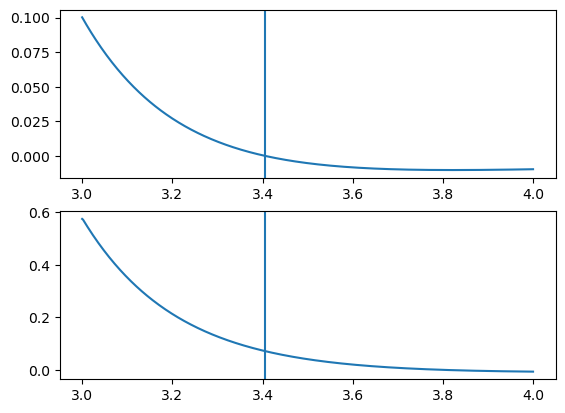

In [ ]:
import numpy as np

class MorsePotential(InteratomicPotential):
    class Parameters():
        def __init__(self, De, a, re):
            self.De = De # Well depth (Dissociation energy)
            self.a = a   # Width of the potential (Stiffness)
            self.re = re # Equilibrium bond distance

    def eval(self, r: float):
        De = self.parameters.De
        a = self.parameters.a
        re = self.parameters.re
        
        # Morse Formula: V(r) = De * (1 - exp(-a * (r - re)))^2 - De
        # Note: We subtract De to set the minimum at -De (consistent with LJ)
        V = De * (1 - np.exp(-a * (r - re)))**2 - De
        return V

# Parameters for a "generic" breakable bond
morse_params = MorsePotential.Parameters(
    De = 0.1,    # Depth of the well
    a = 1.5,     # Sharpness of the curve
    re = 3.822   # Same equilibrium as your Argon LJ model
)

# Plotting this will show a much more realistic "tail" 
# as the atoms pull apart.
